In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("../data/ecommerce_sales_analytics_5000.csv")
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,1/1/2022,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,1/2/2022,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,1/3/2022,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,1/4/2022,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,1/5/2022,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [3]:
df.shape

(5000, 12)

In [4]:
df.columns

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   str    
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   str    
 4   region            5000 non-null   str    
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   str    
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
dtypes: float64(4), int64(4), str(4)
memory usage: 468.9 KB


In [6]:
df.isnull().sum()

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df["order_date"] = pd.to_datetime(df["order_date"])
df.dtypes

order_id                     int64
order_date          datetime64[us]
customer_id                  int64
product_category               str
region                         str
quantity                     int64
unit_price                 float64
discount                   float64
payment_method                 str
delivery_days                int64
customer_rating            float64
revenue                    float64
dtype: object

In [9]:
print("Start date:", df["order_date"].min())
print("End date:", df["order_date"].max())

Start date: 2022-01-01 00:00:00
End date: 2035-09-09 00:00:00


In [10]:
df.describe()

,order_id,order_date,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2028-11-04 12:00:00,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148
min,10001.000000,2022-01-01 00:00:00,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000
25%,11250.750000,2025-06-03 18:00:00,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500
50%,12500.500000,2028-11-04 12:00:00,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000
75%,13750.250000,2032-04-07 06:00:00,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000
max,15000.000000,2035-09-09 00:00:00,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000
std,1443.520003,NaN,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219


In [11]:
df["calculated_revenue"] = (
    df["quantity"]
    * df["unit_price"]
    * (1 - df["discount"])
).round(2)

df["revenue_difference"] = (
    df["revenue"] - df["calculated_revenue"]
).round(2)

df["revenue_difference"].abs().max()

np.float64(0.0)

In [12]:
df.drop(
    columns=["calculated_revenue", "revenue_difference"],
    inplace=True
)
df.head()

,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue
0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20
1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10
2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35
3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90
4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56


In [13]:
print("Total Orders:", len(df))
print("Unique Customers:", df["customer_id"].nunique())
print("Total Revenue: ฿", round(df["revenue"].sum(), 2))
print("Average Order Revenue: ฿", round(df["revenue"].mean(), 2))
print("Total Quantity Sold:", df["quantity"].sum())
print("Average Delivery Days:", round(df["delivery_days"].mean(), 2))
print("Average Customer Rating:", round(df["customer_rating"].mean(), 2))
print("Average Discount:", round(df["discount"].mean() * 100, 2), "%")

Total Orders: 5000
Unique Customers: 989
Total Revenue: ฿ 5109775.74
Average Order Revenue: ฿ 1021.96
Total Quantity Sold: 20224
Average Delivery Days: 6.12
Average Customer Rating: 2.97
Average Discount: 18.0 %


In [14]:
category_revenue = (
    df.groupby("product_category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

category_revenue

product_category
Electronics    1829899.22
Clothing       1531931.72
Home            982083.92
Beauty          765860.88
Name: revenue, dtype: float64

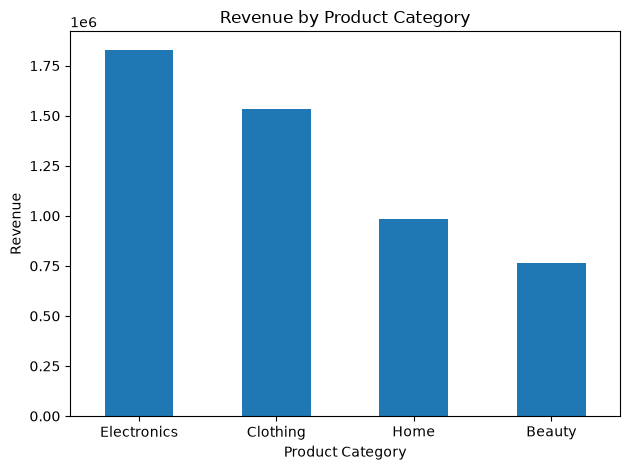

In [15]:
import matplotlib.pyplot as plt

category_revenue.plot(kind="bar")

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

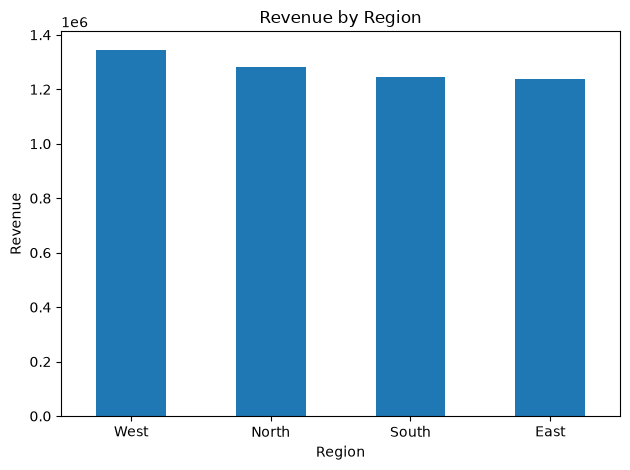

In [16]:
region_revenue = (
    df.groupby("region")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

region_revenue

region_revenue.plot(kind="bar")

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

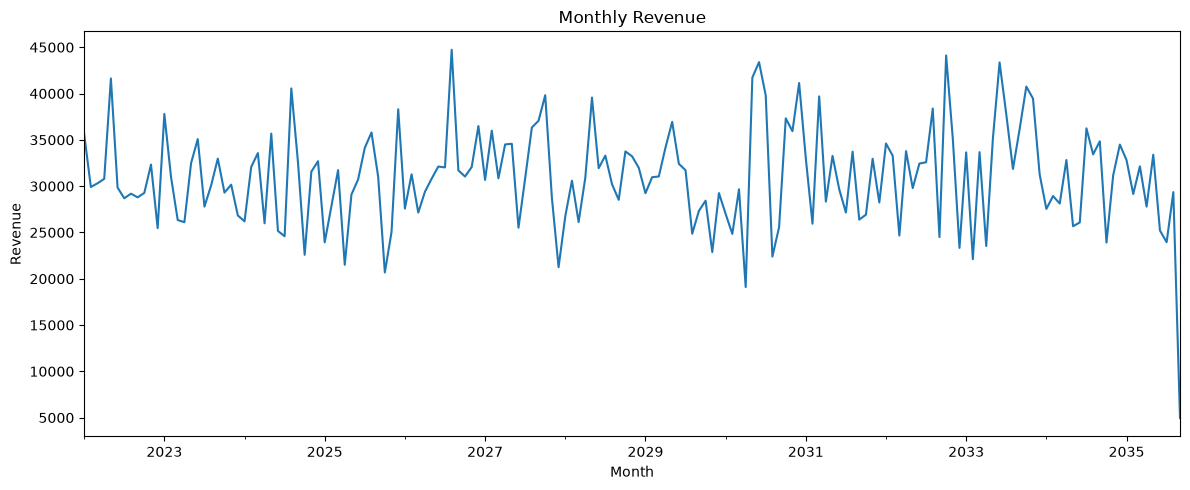

In [17]:
monthly_revenue = (
    df.groupby(df["order_date"].dt.to_period("M"))["revenue"]
    .sum()
)

monthly_revenue.plot(kind="line", figsize=(12, 5))

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.tight_layout()
plt.show()

In [18]:
monthly_summary = (
    df.groupby(df["order_date"].dt.to_period("M"))
    .agg(
        orders=("order_id", "count"),
        revenue=("revenue", "sum")
    )
    .reset_index()
)

monthly_summary.tail(10)

,order_date,orders,revenue
155,2034-12,31,34488.78
156,2035-01,31,32810.04
157,2035-02,28,29147.77
158,2035-03,31,32136.73
159,2035-04,30,27788.24
160,2035-05,31,33393.87
161,2035-06,30,25205.26
162,2035-07,31,23944.48
163,2035-08,31,29354.74
164,2035-09,9,4952.23


In [19]:
monthly_summary.head(10)

,order_date,orders,revenue
0,2022-01,31,35624.89
1,2022-02,28,29908.89
2,2022-03,31,30309.28
3,2022-04,30,30781.96
4,2022-05,31,41629.24
5,2022-06,30,29847.33
6,2022-07,31,28686.24
7,2022-08,31,29186.45
8,2022-09,30,28791.07
9,2022-10,31,29265.55


In [20]:
df[[
    "quantity",
    "unit_price",
    "discount",
    "delivery_days",
    "customer_rating",
    "revenue"
]].describe().round(2)

,quantity,unit_price,discount,delivery_days,customer_rating,revenue
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,4.04,308.42,0.18,6.12,2.97,1021.96
std,2.02,169.26,0.10,3.15,1.16,825.58
min,1.00,15.15,0.00,1.00,1.00,11.21
25%,2.00,161.90,0.09,3.00,2.00,354.53
50%,4.00,309.89,0.18,6.00,3.00,796.65
75%,6.00,455.56,0.27,9.00,4.00,1515.69
max,7.00,599.96,0.35,11.00,5.00,4119.33


In [21]:
rating_by_delivery = (
    df.groupby("delivery_days")["customer_rating"]
    .mean()
    .round(2)
)

rating_by_delivery

delivery_days
1     2.99
2     2.94
3     2.93
4     3.07
5     3.04
6     2.96
7     3.02
8     2.99
9     2.95
10    2.92
11    2.89
Name: customer_rating, dtype: float64

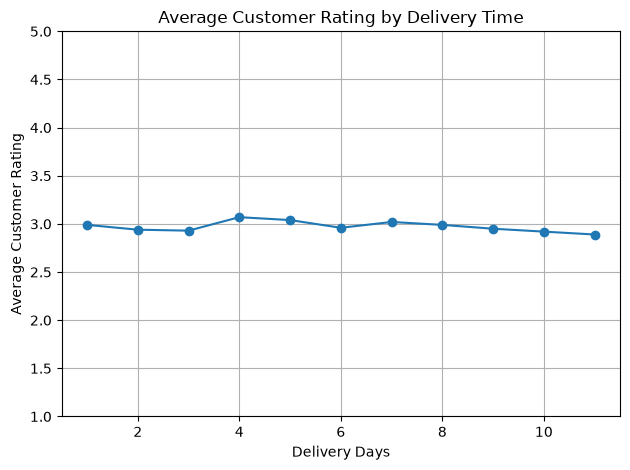

In [22]:
rating_by_delivery.plot(kind="line", marker="o")

plt.title("Average Customer Rating by Delivery Time")
plt.xlabel("Delivery Days")
plt.ylabel("Average Customer Rating")
plt.ylim(1, 5)
plt.grid(True)
plt.tight_layout()
plt.show()

In [23]:
df["delivery_days"].corr(df["customer_rating"])

np.float64(-0.017624942276440268)

In [24]:
discount_analysis = (
    df.groupby("discount")
    .agg(
        orders=("order_id", "count"),
        total_revenue=("revenue", "sum"),
        average_revenue=("revenue", "mean")
    )
    .round(2)
)

discount_analysis

,orders,total_revenue,average_revenue
discount,,,
0.00,68,81686.86,1201.28
0.01,123,145677.84,1184.37
0.02,160,201162.79,1257.27
0.03,138,174058.16,1261.29
0.04,131,142728.74,1089.53
0.05,128,158456.80,1237.94
0.06,133,165679.87,1245.71
0.07,125,141067.34,1128.54
0.08,142,160579.10,1130.84


In [25]:
df["discount"].corr(df["revenue"])

np.float64(-0.13929560296730728)

In [26]:
customer_analysis = (
    df.groupby("customer_id")
    .agg(
        orders=("order_id", "count"),
        total_revenue=("revenue", "sum"),
        average_order_value=("revenue", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

customer_analysis.head(10)

,orders,total_revenue,average_order_value
customer_id,,,
1663,14,17680.69,1262.906429
1955,10,16265.15,1626.515000
1675,11,15036.46,1366.950909
1276,11,15023.71,1365.791818
1647,11,14894.97,1354.088182
1804,10,14330.98,1433.098000
1193,7,14151.65,2021.664286
1836,9,14110.78,1567.864444
1957,12,13956.95,1163.079167


In [27]:
customer_analysis.describe().round(2)

,orders,total_revenue,average_order_value
count,989.00,989.00,989.00
mean,5.06,5166.61,1020.35
std,2.33,2952.39,408.00
min,1.00,119.06,119.06
25%,3.00,3024.67,737.19
50%,5.00,4832.82,1008.54
75%,6.00,6983.14,1268.89
max,14.00,17680.69,2890.44


In [28]:
customer_analysis.sort_values("orders", ascending=False).head(10)

,orders,total_revenue,average_order_value
customer_id,,,
1663,14,17680.69,1262.906429
1957,12,13956.95,1163.079167
1669,12,10572.84,881.070000
1038,12,10483.21,873.600833
1098,12,10373.53,864.460833
1928,12,9480.66,790.055000
1935,12,12656.45,1054.704167
1112,12,7857.55,654.795833
1612,11,11725.79,1065.980909


In [29]:
category_analysis = (
    df.groupby("product_category")
    .agg(
        orders=("order_id", "count"),
        total_quantity=("quantity", "sum"),
        total_revenue=("revenue", "sum"),
        average_revenue=("revenue", "mean"),
        average_rating=("customer_rating", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .round(2)
)

category_analysis

,orders,total_quantity,total_revenue,average_revenue,average_rating
product_category,,,,,
Electronics,1777,7109,1829899.22,1029.77,2.95
Clothing,1531,6171,1531931.72,1000.61,3.01
Home,969,3949,982083.92,1013.50,2.94
Beauty,723,2995,765860.88,1059.28,3.01


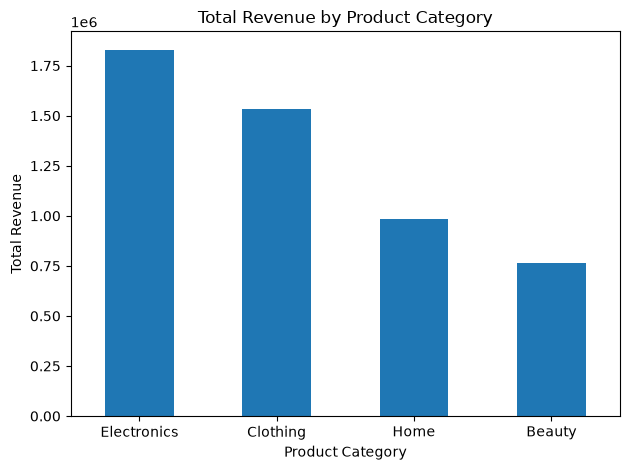

In [30]:
category_analysis["total_revenue"].plot(kind="bar")

plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

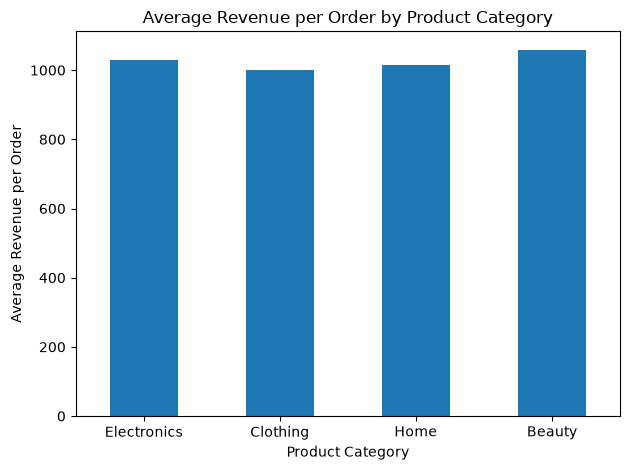

In [31]:
category_analysis["average_revenue"].plot(kind="bar")

plt.title("Average Revenue per Order by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Average Revenue per Order")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [32]:
region_analysis = (
    df.groupby("region")
    .agg(
        orders=("order_id", "count"),
        total_quantity=("quantity", "sum"),
        total_revenue=("revenue", "sum"),
        average_revenue=("revenue", "mean"),
        average_delivery_days=("delivery_days", "mean"),
        average_rating=("customer_rating", "mean")
    )
    .sort_values("total_revenue", ascending=False)
    .round(2)
)

region_analysis

,orders,total_quantity,total_revenue,average_revenue,average_delivery_days,average_rating
region,,,,,,
West,1289,5260,1345582.16,1043.90,6.08,2.96
North,1276,5164,1281508.45,1004.32,6.12,2.99
South,1208,4884,1246640.90,1031.99,6.17,2.97
East,1227,4916,1236044.23,1007.37,6.10,2.97


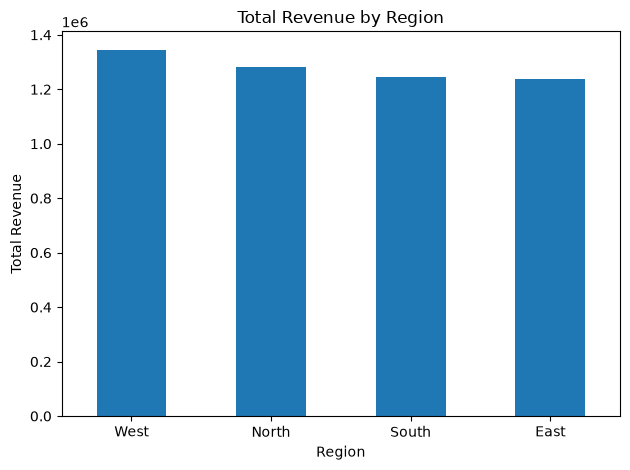

In [33]:
region_analysis["total_revenue"].plot(kind="bar")

plt.title("Total Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

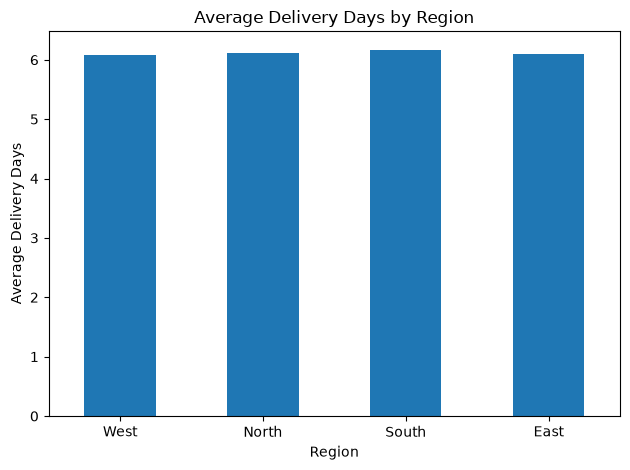

In [34]:
region_analysis["average_delivery_days"].plot(kind="bar")

plt.title("Average Delivery Days by Region")
plt.xlabel("Region")
plt.ylabel("Average Delivery Days")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()